About this Dataset: Netflix is one of the most popular media and video streaming platforms. They have over 8000 movies or tv shows available on their platform, as of mid-2021, they have over 200M Subscribers globally. This tabular dataset consists of listings of all the movies and tv shows available on Netflix, along with details such as - cast, directors, ratings, release year, duration, etc.

In [ ]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA ASSESSMENT (LOAD & INSPECT)

In [ ]:
movies = pd.read_csv("/content/netflix_titles.csv")
df = movies.copy()

In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
df.shape

(8807, 12)

In [ ]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
# null values
df.isnull().sum()

# percentage null values
df.isnull().sum()/len(df)*100

,0
show_id,0.000000
type,0.000000
title,0.000000
director,29.908028
cast,9.367549
country,9.435676
date_added,0.113546
release_year,0.000000
rating,0.045418
duration,0.034064


In [ ]:
df.duplicated().sum() # zero duplicated rows

np.int64(0)

In [ ]:
df.nunique() # unique values in each rows

,0
show_id,8807
type,2
title,8807
director,4528
cast,7692
country,748
date_added,1767
release_year,74
rating,17
duration,220


In [ ]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [ ]:
df['rating'].value_counts() # rating column have 3 wrong values -- 74 min,84 min,66 min.

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


Data Assessment Summary :
  1. missing values in columns - director,cast,country,date_added,rating,duration.
  2. date_added column data type is object converted to datetime.
  3. duration column have mixed value of seasons and minutes.
  4. rating column have 3 wrong values.

DATA CLEANING :-

In [ ]:
# Handling missing value

mask = df['rating'].str.contains('min',na = False)
df[mask][['title','rating','duration']]

,title,rating,duration
5541,Louis C.K. 2017,74 min,NaN
5794,Louis C.K.: Hilarious,84 min,NaN
5813,Louis C.K.: Live at the Comedy Store,66 min,NaN


In [ ]:
df.loc[mask,'duration'] = df.loc[mask,'rating']
df.loc[mask,'rating'] = np.nan
df[mask][['title','rating','duration']]

,title,rating,duration
5541,Louis C.K. 2017,NaN,74 min
5794,Louis C.K.: Hilarious,NaN,84 min
5813,Louis C.K.: Live at the Comedy Store,NaN,66 min


In [ ]:
df['director'].fillna('Unknown',inplace = True)
df['cast'].fillna('Unknown',inplace = True)
df['country'].fillna('Unknown',inplace = True)
df['rating'].fillna('NR',inplace = True)
df[['director','cast','country','rating']].isnull().sum()

/tmp/ipykernel_5390/1105635220.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('Unknown',inplace = True)
/tmp/ipykernel_5390/1105635220.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

,0
director,0
cast,0
country,0
rating,0


In [ ]:
df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'],errors='coerce')

df[df['date_added'].isnull()] # date_added column left with 10 NaT values.

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
6066,s6067,TV Show,A Young Doctor's Notebook and Other Stories,Unknown,"Daniel Radcliffe, Jon Hamm, Adam Godley, Chris...",United Kingdom,NaT,2013,TV-MA,2 Seasons,"British TV Shows, TV Comedies, TV Dramas","Set during the Russian Revolution, this comic ..."
6174,s6175,TV Show,Anthony Bourdain: Parts Unknown,Unknown,Anthony Bourdain,United States,NaT,2018,TV-PG,5 Seasons,Docuseries,This CNN original series has chef Anthony Bour...
6795,s6796,TV Show,Frasier,Unknown,"Kelsey Grammer, Jane Leeves, David Hyde Pierce...",United States,NaT,2003,TV-PG,11 Seasons,"Classic & Cult TV, TV Comedies",Frasier Crane is a snooty but lovable Seattle ...
6806,s6807,TV Show,Friends,Unknown,"Jennifer Aniston, Courteney Cox, Lisa Kudrow, ...",United States,NaT,2003,TV-14,10 Seasons,"Classic & Cult TV, TV Comedies",This hit sitcom follows the merry misadventure...
6901,s6902,TV Show,Gunslinger Girl,Unknown,"Yuuka Nanri, Kanako Mitsuhashi, Eri Sendai, Am...",Japan,NaT,2008,TV-14,2 Seasons,"Anime Series, Crime TV Shows","On the surface, the Social Welfare Agency appe..."
7196,s7197,TV Show,Kikoriki,Unknown,Igor Dmitriev,Unknown,NaT,2010,TV-Y,2 Seasons,Kids' TV,A wacky rabbit and his gang of animal pals hav...
7254,s7255,TV Show,La Familia P. Luche,Unknown,"Eugenio Derbez, Consuelo Duval, Luis Manuel Áv...",United States,NaT,2012,TV-14,3 Seasons,"International TV Shows, Spanish-Language TV Sh...","This irreverent sitcom featues Ludovico, Feder..."
7406,s7407,TV Show,Maron,Unknown,"Marc Maron, Judd Hirsch, Josh Brener, Nora Zeh...",United States,NaT,2016,TV-MA,4 Seasons,TV Comedies,"Marc Maron stars as Marc Maron, who interviews..."
7847,s7848,TV Show,Red vs. Blue,Unknown,"Burnie Burns, Jason Saldaña, Gustavo Sorola, G...",United States,NaT,2015,NR,13 Seasons,"TV Action & Adventure, TV Comedies, TV Sci-Fi ...","This parody of first-person shooter games, mil..."
8182,s8183,TV Show,The Adventures of Figaro Pho,Unknown,"Luke Jurevicius, Craig Behenna, Charlotte Haml...",Australia,NaT,2015,TV-Y7,2 Seasons,"Kids' TV, TV Comedies","Imagine your worst fears, then multiply them: ..."


In [ ]:
df['duration_value'] = df['duration'].str.extract(r'(\d+)')[0].astype(int)
df['duration_unit'] = df['duration'].str.extract(r'([a-zA-Z ]+)')[0].str.strip()
df[['duration','duration_value','duration_unit']].head(5)

df['duration_unit'].unique()

array(['min', 'Seasons', 'Season'], dtype=object)

In [ ]:
df.describe(include='object')

,show_id,type,title,director,cast,country,rating,duration,listed_in,description,duration_unit
count,8807,8807,8807,8807,8807,8807,8807,8807,8807,8807,8807
unique,8807,2,8807,4529,7693,749,14,220,514,8775,3
top,s8807,Movie,Zubaan,Unknown,Unknown,United States,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope...",min
freq,1,6131,1,2634,825,2818,3207,1793,362,4,6131


In [ ]:
df.isna().sum() # date column has left with 10 NaT values.
df[df['date_added'].isna()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_value,duration_unit
6066,s6067,TV Show,A Young Doctor's Notebook and Other Stories,Unknown,"Daniel Radcliffe, Jon Hamm, Adam Godley, Chris...",United Kingdom,NaT,2013,TV-MA,2 Seasons,"British TV Shows, TV Comedies, TV Dramas","Set during the Russian Revolution, this comic ...",2,Seasons
6174,s6175,TV Show,Anthony Bourdain: Parts Unknown,Unknown,Anthony Bourdain,United States,NaT,2018,TV-PG,5 Seasons,Docuseries,This CNN original series has chef Anthony Bour...,5,Seasons
6795,s6796,TV Show,Frasier,Unknown,"Kelsey Grammer, Jane Leeves, David Hyde Pierce...",United States,NaT,2003,TV-PG,11 Seasons,"Classic & Cult TV, TV Comedies",Frasier Crane is a snooty but lovable Seattle ...,11,Seasons
6806,s6807,TV Show,Friends,Unknown,"Jennifer Aniston, Courteney Cox, Lisa Kudrow, ...",United States,NaT,2003,TV-14,10 Seasons,"Classic & Cult TV, TV Comedies",This hit sitcom follows the merry misadventure...,10,Seasons
6901,s6902,TV Show,Gunslinger Girl,Unknown,"Yuuka Nanri, Kanako Mitsuhashi, Eri Sendai, Am...",Japan,NaT,2008,TV-14,2 Seasons,"Anime Series, Crime TV Shows","On the surface, the Social Welfare Agency appe...",2,Seasons
7196,s7197,TV Show,Kikoriki,Unknown,Igor Dmitriev,Unknown,NaT,2010,TV-Y,2 Seasons,Kids' TV,A wacky rabbit and his gang of animal pals hav...,2,Seasons
7254,s7255,TV Show,La Familia P. Luche,Unknown,"Eugenio Derbez, Consuelo Duval, Luis Manuel Áv...",United States,NaT,2012,TV-14,3 Seasons,"International TV Shows, Spanish-Language TV Sh...","This irreverent sitcom featues Ludovico, Feder...",3,Seasons
7406,s7407,TV Show,Maron,Unknown,"Marc Maron, Judd Hirsch, Josh Brener, Nora Zeh...",United States,NaT,2016,TV-MA,4 Seasons,TV Comedies,"Marc Maron stars as Marc Maron, who interviews...",4,Seasons
7847,s7848,TV Show,Red vs. Blue,Unknown,"Burnie Burns, Jason Saldaña, Gustavo Sorola, G...",United States,NaT,2015,NR,13 Seasons,"TV Action & Adventure, TV Comedies, TV Sci-Fi ...","This parody of first-person shooter games, mil...",13,Seasons
8182,s8183,TV Show,The Adventures of Figaro Pho,Unknown,"Luke Jurevicius, Craig Behenna, Charlotte Haml...",Australia,NaT,2015,TV-Y7,2 Seasons,"Kids' TV, TV Comedies","Imagine your worst fears, then multiply them: ...",2,Seasons


Feature Engineering :-

In [ ]:
# 3 column were added year_added,month_added,month_name

df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
df['month_name'] = df['date_added'].dt.strftime('%B')


In [ ]:
df['years_gap'] = df['year_added'] - df['release_year']

df.shape

(8807, 18)

In [ ]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'duration_value', 'duration_unit', 'year_added', 'month_added',
       'month_name', 'years_gap'],
      dtype='object')

In [ ]:
df = df.dropna(subset=['date_added'])

df['year_added']  = df['year_added'].astype(int)
df['month_added'] = df['month_added'].astype(int)
df['years_gap']   = df['years_gap'].astype(int)


print(df.shape)
print(df[['year_added','month_added','years_gap']].dtypes)

(8797, 18)
year_added     int64
month_added    int64
years_gap      int64
dtype: object


/tmp/ipykernel_5390/1048924879.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['year_added']  = df['year_added'].astype(int)
/tmp/ipykernel_5390/1048924879.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month_added'] = df['month_added'].astype(int)
/tmp/ipykernel_5390/1048924879.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.o

In [ ]:
df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_value,duration_unit,year_added,month_added,month_name,years_gap
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90,min,2021,9,September,1
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2,Seasons,2021,9,September,0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1,Season,2021,9,September,0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1,Season,2021,9,September,0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2,Seasons,2021,9,September,0


Exploratory Data Analysis (EDA) :-

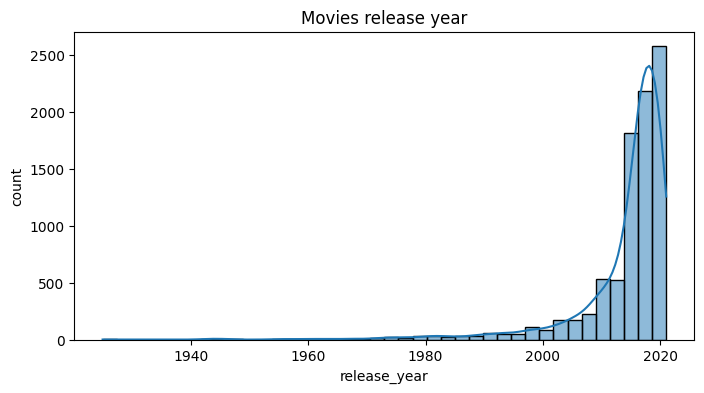

In [ ]:
# Univariate analysis on  - (release_year,year_added,month_added,year_gap)

df['release_year'].describe()

plt.figure(figsize=(8,4))
sns.histplot(df['release_year'],bins = 40,kde = True)
plt.title('Movies release year')
plt.xlabel('release_year')
plt.ylabel('count')
plt.show()

In [ ]:
year_counts = df["release_year"].value_counts().sort_index()
year_counts

,count
release_year,
1925,1
1942,2
1943,3
1944,3
1945,4
...,...
2017,1032
2018,1146
2019,1030


Release Year Trends :

  - Netflix content gradually increased after 2000.
  - Peaks appear in recent years showing more content production.
  - This can indicate expansion strategy or popularity growth.

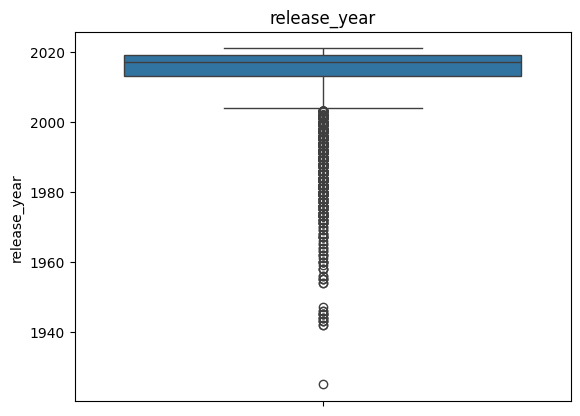

In [ ]:
sns.boxplot(df['release_year'])
plt.title('release_year')
plt.show()

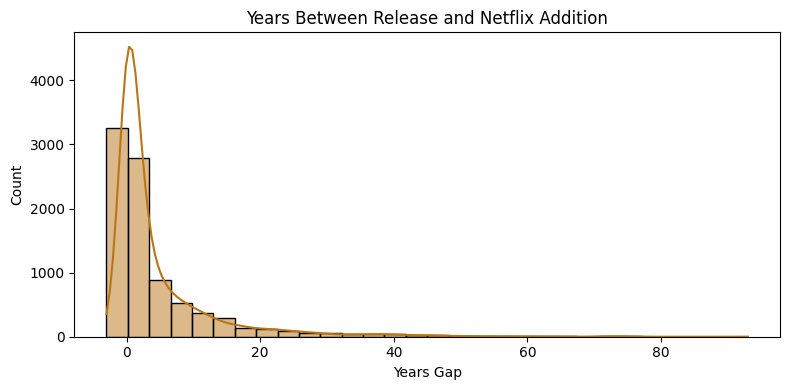

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(df["years_gap"].dropna(), bins=30, kde=True, color="#BA7517")
plt.title("Years Between Release and Netflix Addition")
plt.xlabel("Years Gap")
plt.tight_layout()
plt.show()

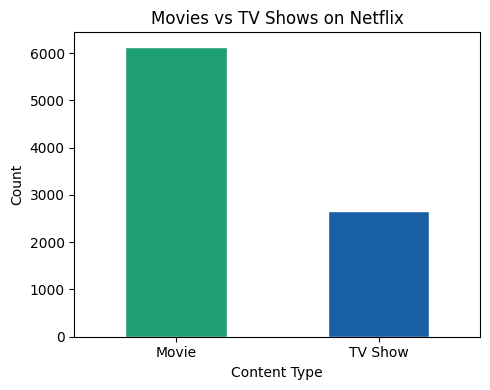

In [ ]:
# univariate analysis on categorical columns


k = df['type'].value_counts(normalize = True)*100
df["type"].value_counts().plot(
    kind="bar",
    color=["#1D9E75", "#185FA5"],
    figsize=(5, 4),
    edgecolor="white"
)
plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Movies vs TV Shows

  From the chart above, we can see that:

   - Netflix has more Movies (6131) than TV Shows (2673) in this dataset.
   - This could indicate a stronger focus on Movies or the dataset being collected over time may have more Movie entries.
   - Such insights help understand content strategy or data

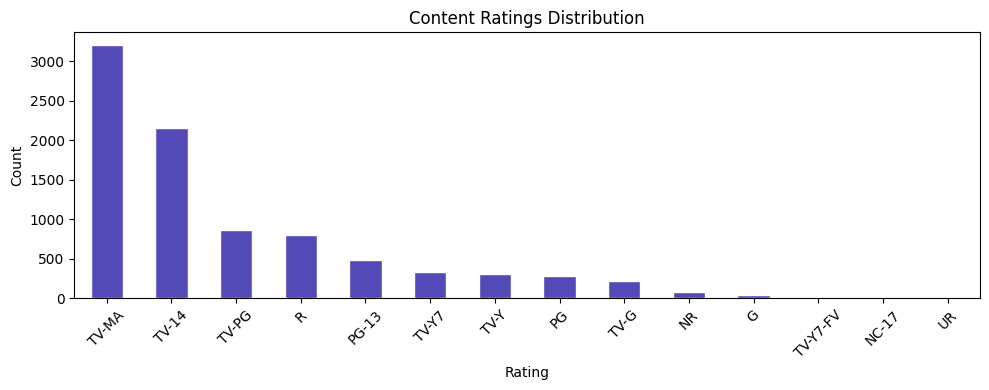

In [ ]:
df["rating"].value_counts().plot(
    kind="bar",
    color="#534AB7",
    figsize=(10, 4),
    edgecolor="white"
)
plt.title("Content Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Ratings

From the chart above, we can see that:

  - Heavy adult lean: Dominance of TV-MA and TV-14 content over all other categories.

  - Moderate family footprint: Noticeably fewer titles for kids and general audiences (TV-Y, TV-G, G).

  - Niche/unrated rarity: Minimal presence of specialized or unrated content (NC-17, NR, UR).

  - Clear right-skewed distribution: Rapid drop-off in volume moving from mature to general ratings.

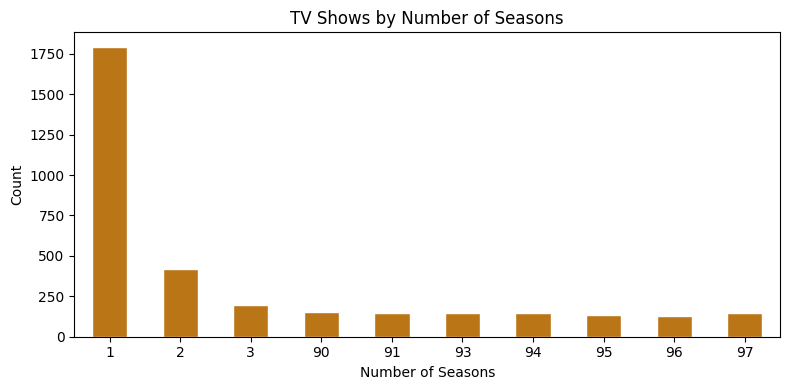

In [ ]:
df["duration_value"].value_counts().head(10).sort_index().plot(
    kind="bar",
    color="#BA7517",
    figsize=(8, 4),
    edgecolor="white"
)
plt.title("TV Shows by Number of Seasons")
plt.xlabel("Number of Seasons")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


=== Titles Added Per Year ===
year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2016
2020    1879
2021    1498
Name: title, dtype: int64


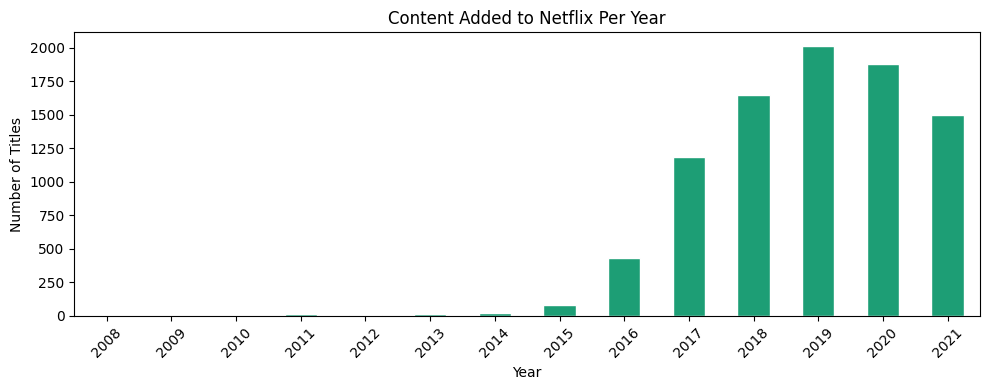

In [ ]:
# bivariate anaylsis

print("\n=== Titles Added Per Year ===")
yearly = df.groupby("year_added")["title"].count()
print(yearly)
# Expected: explosive growth from 2016, peak at 2019 (2016 titles)

yearly.plot(
    kind="bar",
    figsize=(10, 4),
    color="#1D9E75",
    edgecolor="white"
)
plt.title("Content Added to Netflix Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


=== Movies vs TV Shows Per Year ===
type         Movie  TV Show
year_added                 
2008           1.0      1.0
2009           2.0      0.0
2010           1.0      0.0
2011          13.0      0.0
2012           3.0      0.0
2013           6.0      5.0
2014          19.0      5.0
2015          56.0     26.0
2016         253.0    176.0
2017         839.0    349.0
2018        1237.0    412.0
2019        1424.0    592.0
2020        1284.0    595.0
2021         993.0    505.0


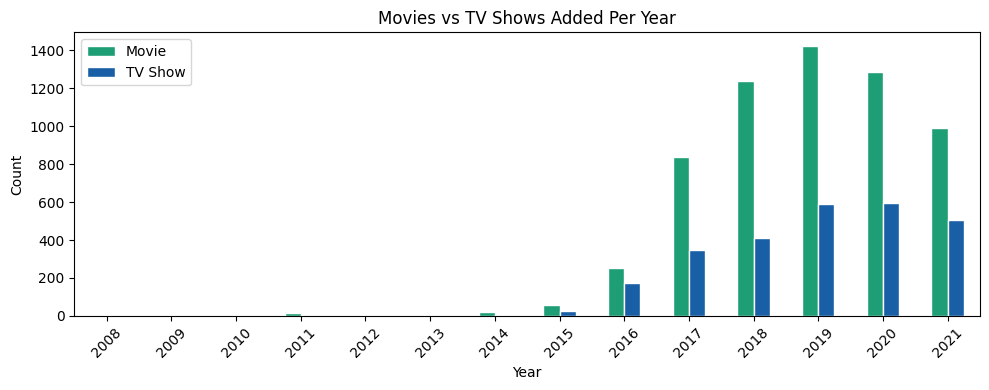

In [ ]:
type_year = (
    df.groupby(["year_added", "type"])["title"]
    .count()
    .unstack()
    .fillna(0)
)
print("\n=== Movies vs TV Shows Per Year ===")
print(type_year)

type_year.plot(
    kind="bar",
    figsize=(10, 4),
    color=["#1D9E75", "#185FA5"],
    edgecolor="white"
)
plt.title("Movies vs TV Shows Added Per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(["Movie", "TV Show"])
plt.tight_layout()
plt.show()



=== Titles Added Per Month ===
month_name
January      738
February     563
March        742
April        764
May          632
June         728
July         827
August       755
September    770
October      760
November     705
December     813
Name: title, dtype: int64


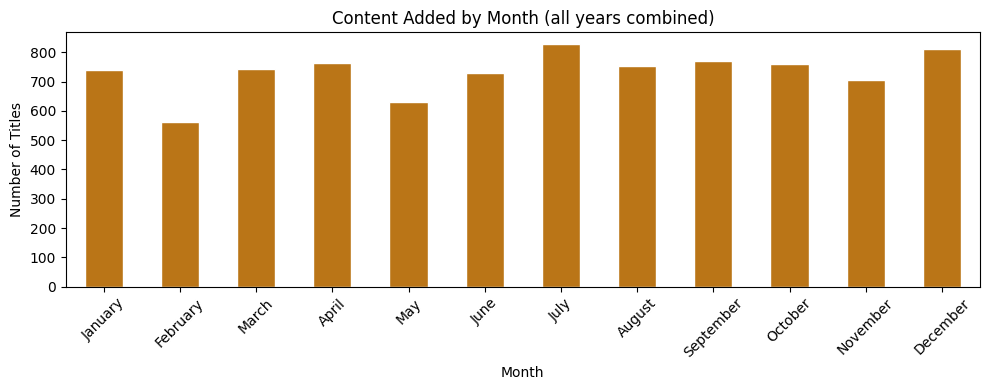

In [ ]:
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]
monthly = df.groupby("month_name")["title"].count().reindex(month_order)
print("\n=== Titles Added Per Month ===")
print(monthly)
# Expected: July and December are peak months

monthly.plot(
    kind="bar",
    figsize=(10, 4),
    color="#BA7517",
    edgecolor="white"
)
plt.title("Content Added by Month (all years combined)")
plt.xlabel("Month")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


=== Top 10 Producing Countries ===
country
United States     3684
India             1046
United Kingdom     805
Canada             445
France             393
Japan              317
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64


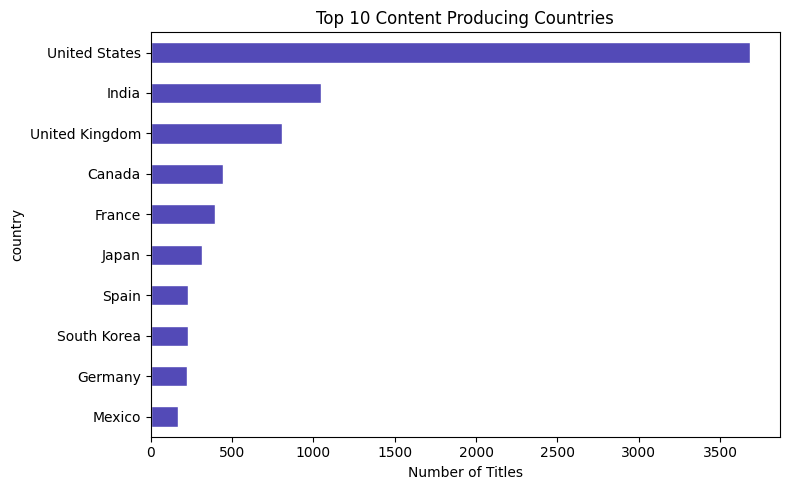

In [ ]:
countries = (
    df[df["country"] != "Unknown"]["country"]
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
)
print("\n=== Top 10 Producing Countries ===")
print(countries)

countries.plot(
    kind="barh",
    figsize=(8, 5),
    color="#534AB7",
    edgecolor="white"
)
plt.title("Top 10 Content Producing Countries")
plt.xlabel("Number of Titles")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


=== Top 12 Genres ===
listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1350
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Thrillers                    577
TV Comedies                  574
Name: count, dtype: int64


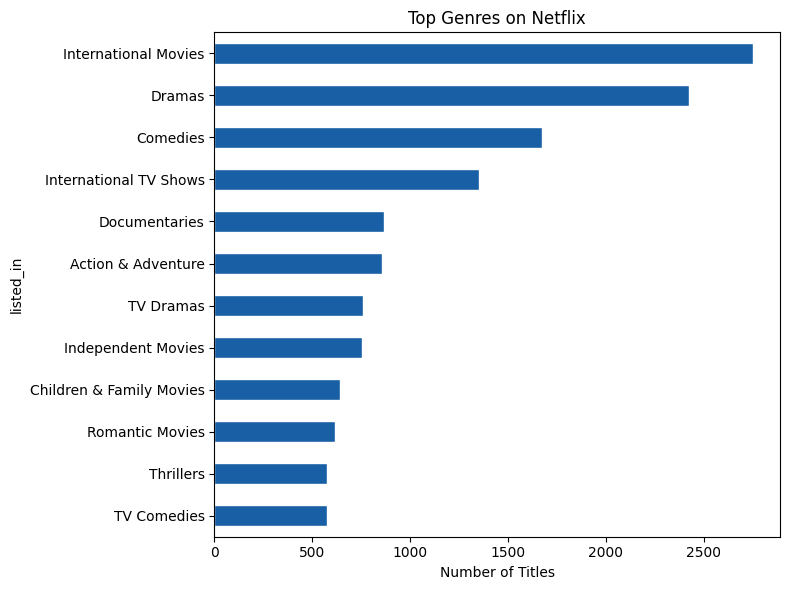

In [ ]:
genres = (
    df["listed_in"]
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
    .head(12)
)
print("\n=== Top 12 Genres ===")
print(genres)

genres.plot(
    kind="barh",
    figsize=(8, 6),
    color="#185FA5",
    edgecolor="white"
)
plt.title("Top Genres on Netflix")
plt.xlabel("Number of Titles")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

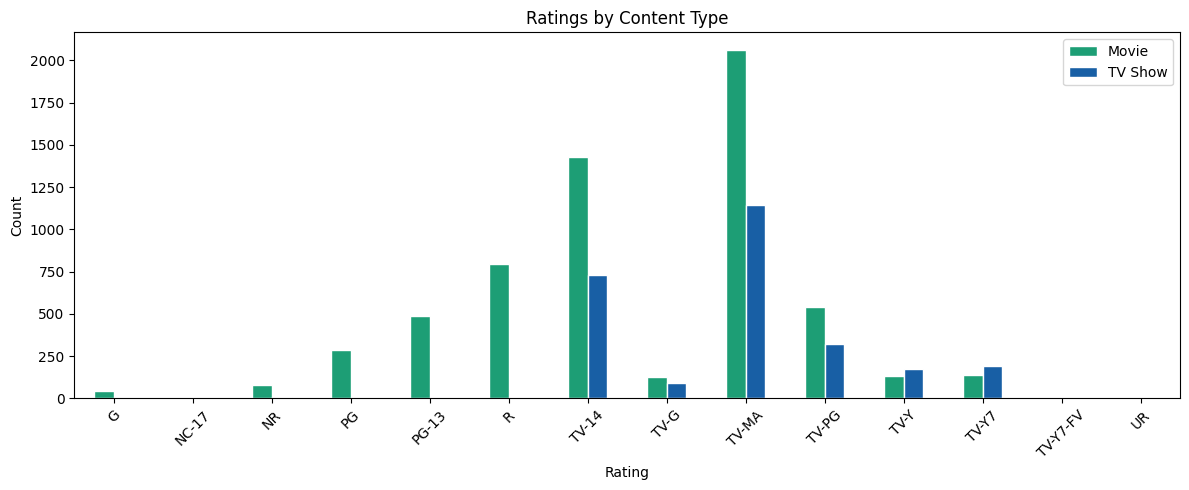

In [ ]:
df.groupby(["type", "rating"])["title"].count().unstack().T.plot(
    kind="bar",
    figsize=(12, 5),
    color=["#1D9E75", "#185FA5"],
    edgecolor="white"
)
plt.title("Ratings by Content Type")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(["Movie", "TV Show"])
plt.tight_layout()
plt.show()


=== years_gap by type ===
          count      mean       std  min  25%  50%  75%   max
type                                                         
Movie    6131.0  5.727777  9.742631 -1.0  0.0  2.0  7.0  75.0
TV Show  2666.0  2.298200  5.320636 -3.0  0.0  0.0  2.0  93.0


/tmp/ipykernel_1585/2657217932.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="type", y="years_gap", data=df, palette=["#1D9E75", "#185FA5"])


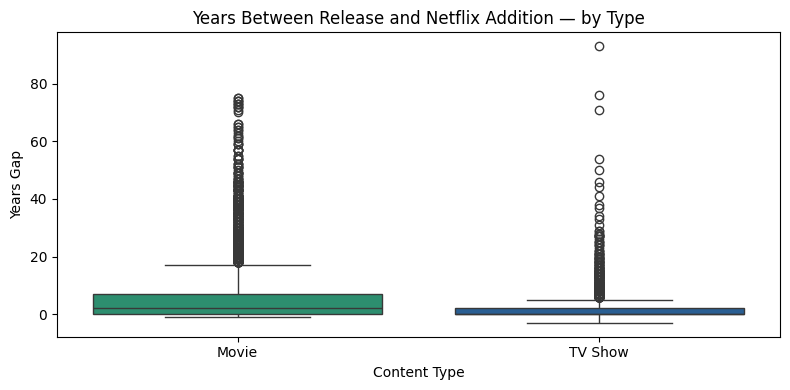

In [ ]:
print("\n=== years_gap by type ===")
print(df.groupby("type")["years_gap"].describe())

plt.figure(figsize=(8, 4))
sns.boxplot(x="type", y="years_gap", data=df, palette=["#1D9E75", "#185FA5"])
plt.title("Years Between Release and Netflix Addition — by Type")
plt.xlabel("Content Type")
plt.ylabel("Years Gap")
plt.tight_layout()
plt.show()

Multi variate analysis

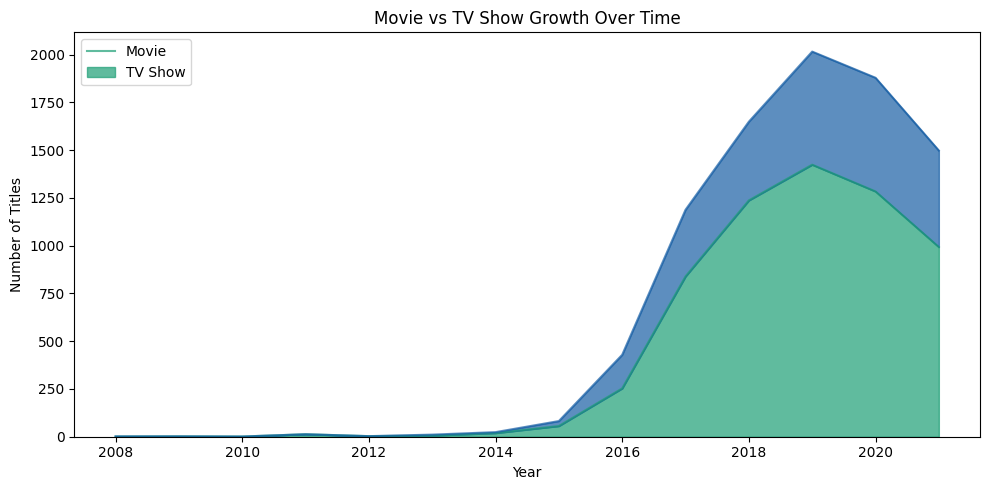

In [ ]:
type_trend = (
    df.groupby(["year_added", "type"])["title"]
    .count()
    .unstack()
    .fillna(0)
)
type_trend.plot(
    kind="area",
    figsize=(10, 5),
    alpha=0.7,
    color=["#1D9E75", "#185FA5"]
)
plt.title("Movie vs TV Show Growth Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.legend(["Movie", "TV Show"])
plt.tight_layout()
plt.show()

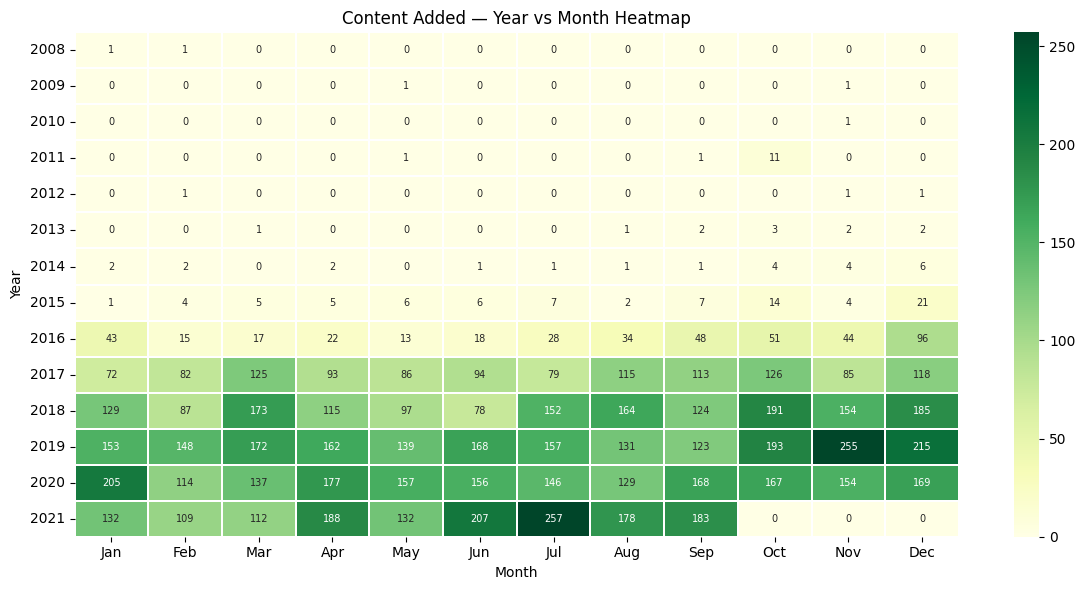

In [ ]:
month_order = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

df["month_short"] = df["date_added"].dt.strftime("%b")
heatmap_data = (
    df.groupby(["year_added", "month_short"])["title"]
    .count()
    .unstack()
    .reindex(columns=month_order)
    .fillna(0)
)

plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_data,
    cmap="YlGn",
    linewidths=0.3,
    annot=True,
    fmt=".0f",
    annot_kws={"size": 7}
)
plt.title("Content Added — Year vs Month Heatmap")
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.show()
